In [41]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

# ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# SHAP
import shap


ModuleNotFoundError: No module named 'shap'

In [24]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH = "/Users/kratikaneekhra_01/Documents/Smart Health Monitoring /Dataset/heart.csv"

OUTPUT_DIR = "research_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TEST_SIZE = 0.20

NameError: name 'tf' is not defined

In [25]:
print("\n" + "=" * 70)
print("LOADING DATASET")
print("=" * 70)

df = pd.read_csv(DATA_PATH)

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


LOADING DATASET


NameError: name 'DATA_PATH' is not defined

In [42]:
pip install shap;

  Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl (490 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 839.2 kB/s  0:00:49m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 774.1 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [27]:
%pip install numpy pandas matplotlib seaborn scikit-learn joblib xgboost tensorflow


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nStatistical summary:")
print(df.describe(include="all").T)

print("\nUnique values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

TARGET = "HeartDisease"

print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget percentage:")
print(df[TARGET].value_counts(normalize=True) * 100)


EXPLORATORY DATA ANALYSIS

Statistical summary:


NameError: name 'df' is not defined

In [29]:
print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Invalid values in the dataset
if "Cholesterol" in df.columns:
    print(
        "\nZero Cholesterol:",
        (df["Cholesterol"] == 0).sum()
    )

if "RestingBP" in df.columns:
    print(
        "Zero RestingBP:",
        (df["RestingBP"] == 0).sum()
    )

# Treat medically implausible zero values as missing
if "Cholesterol" in df.columns:
    df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

if "RestingBP" in df.columns:
    df["RestingBP"] = df["RestingBP"].replace(0, np.nan)




DATA QUALITY CHECK


NameError: name 'df' is not defined

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/01_target_distribution.png",
    dpi=300
)

plt.show()


NameError: name 'df' is not defined

<Figure size 700x500 with 0 Axes>

In [31]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

NameError: name 'df' is not defined

In [32]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/02_correlation_heatmap.png",
    dpi=300
)

plt.show()


NameError: name 'df' is not defined

In [33]:
print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print(
    "\nTraining class distribution:"
)

print(
    y_train.value_counts(normalize=True)
)

print(
    "\nTesting class distribution:"
)

print(
    y_test.value_counts(normalize=True)
)



TRAIN / TEST SPLIT


NameError: name 'X' is not defined

In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median") ),
        ("scaler",StandardScaler()  )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ( "imputer", SimpleImputer(strategy="most_frequent"  )
        ),
        ( "encoder", OneHotEncoder( handle_unknown="ignore" )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ( "num", numeric_pipeline, numeric_features),
        (  "cat", categorical_pipeline, categorical_features  )
    ]
)


NameError: name 'numeric_features' is not defined

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression( max_iter=2000, random_state=RANDOM_STATE),

    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE ),

    "Random Forest":RandomForestClassifier( n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1 ),

    "XGBoost":
        XGBClassifier(  n_estimators=300, max_depth=4, learning_rate=0.03,subsample=0.9,colsample_bytree=0.9, eval_metric="logloss",  random_state=RANDOM_STATE,
            n_jobs=-1  )
}



NameError: name 'XGBClassifier' is not defined

In [36]:
param_grids = {

    "Logistic Regression": {
        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ]
    },

    "Decision Tree": {
        "model__max_depth": [
            3,
            4,
            5,
            6,
            8,
            10,
            None
        ],

        "model__min_samples_split": [
            2,
            5,
            10,
            20
        ],

        "model__min_samples_leaf": [
            1,
            2,
            5,
            10
        ]
    },

    "Random Forest": {
        "model__n_estimators": [
            200,
            400
        ],

        "model__max_depth": [
            5,
            8,
            12,
            None
        ],

        "model__min_samples_split": [
            2,
            5,
            10
        ],

        "model__min_samples_leaf": [
            1,
            2,
            4
        ],

        "model__max_features": [
            "sqrt",
            "log2"
        ]
    },

    "XGBoost": {
        "model__n_estimators": [
            150,
            250,
            350
        ],

        "model__max_depth": [
            2,
            3,
            4,
            5
        ],

        "model__learning_rate": [
            0.01,
            0.03,
            0.05,
            0.1
        ],

        "model__subsample": [
            0.8,
            0.9,
            1.0
        ],

        "model__colsample_bytree": [
            0.8,
            0.9,
            1.0
        ]
    }
}


In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []
trained_models = {}



In [38]:
for name, model in models.items():

    print("\n" + "=" * 70)
    print(f"TRAINING: {name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    start = time.time()

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    training_time = time.time() - start

    best_model = grid.best_estimator_

    trained_models[name] = best_model

    print("\nBest parameters:")
    print(grid.best_params_)

    print(
        "\nBest CV ROC-AUC:",
        round(grid.best_score_, 4)
    )

    # Predictions
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    specificity = tn / (tn + fp)

    npv = tn / (tn + fn)

    brier = brier_score_loss(
        y_test,
        y_prob
    )

    cv_scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    result = {

        "Model": name,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,

        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,

        "Specificity": specificity,
        "NPV": npv,

        "Brier": brier,

        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,

        "CV_Accuracy": cv_scores[
            "test_accuracy"
        ].mean(),

        "CV_Precision": cv_scores[
            "test_precision"
        ].mean(),

        "CV_Recall": cv_scores[
            "test_recall"
        ].mean(),

        "CV_F1": cv_scores[
            "test_f1"
        ].mean(),

        "CV_ROC_AUC": cv_scores[
            "test_roc_auc"
        ].mean(),

        "CV_ROC_AUC_SD": cv_scores[
            "test_roc_auc"
        ].std(),

        "Training_Time": training_time
    }

    cv_results.append(result)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )


NameError: name 'models' is not defined

In [13]:
print("\n" + "=" * 70)
print("TRAINING: ARTIFICIAL NEURAL NETWORK")
print("=" * 70)


# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

# Convert sparse matrix if necessary
if hasattr(
    X_train_processed,
    "toarray"
):
    X_train_processed = X_train_processed.toarray()

if hasattr(
    X_test_processed,
    "toarray"
):
    X_test_processed = X_test_processed.toarray()


input_dim = X_train_processed.shape[1]


def build_ann(input_dim):

    model = Sequential([

        Dense(
            64,
            activation="relu",
            input_shape=(input_dim,)
        ),

        Dropout(0.20),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.10),

        Dense(
            16,
            activation="relu"
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    return model


ann = build_ann(input_dim)

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=15,
    restore_best_weights=True
)

start = time.time()

history = ann.fit(

    X_train_processed,
    y_train,

    validation_split=0.20,

    epochs=150,

    batch_size=32,

    callbacks=[early_stop],

    verbose=0
)

ann_training_time = time.time() - start


# ANN predictions
ann_prob = ann.predict(
    X_test_processed,
    verbose=0
).ravel()

ann_pred = (
    ann_prob >= 0.5
).astype(int)


tn, fp, fn, tp = confusion_matrix(
    y_test,
    ann_pred
).ravel()


ann_result = {

    "Model": "ANN",

    "Accuracy": accuracy_score(
        y_test,
        ann_pred
    ),

    "Precision": precision_score(
        y_test,
        ann_pred
    ),

    "Recall": recall_score(
        y_test,
        ann_pred
    ),

    "F1": f1_score(
        y_test,
        ann_pred
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        ann_prob
    ),

    "PR_AUC": average_precision_score(
        y_test,
        ann_prob
    ),

    "Specificity":
        tn / (tn + fp),

    "NPV":
        tn / (tn + fn),

    "Brier":
        brier_score_loss(
            y_test,
            ann_prob
        ),

    "TP": tp,
    "TN": tn,
    "FP": fp,
    "FN": fn,

    "Training_Time":
        ann_training_time
}

cv_results.append(
    ann_result
)

trained_models["ANN"] = ann




TRAINING: ARTIFICIAL NEURAL NETWORK


NameError: name 'preprocessor' is not defined

In [14]:
results_df = pd.DataFrame(
    cv_results
)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "Specificity",
    "NPV",
    "Brier"
]

print(
    results_df[
        display_columns
    ].round(4)
)


results_df.to_csv(
    f"{OUTPUT_DIR}/model_comparison.csv",
    index=False
)




FINAL MODEL COMPARISON


KeyError: "None of [Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC',\n       'Specificity', 'NPV', 'Brier'],\n      dtype='str')] are in the [columns]"

NameError: name 'OUTPUT_DIR' is not defined

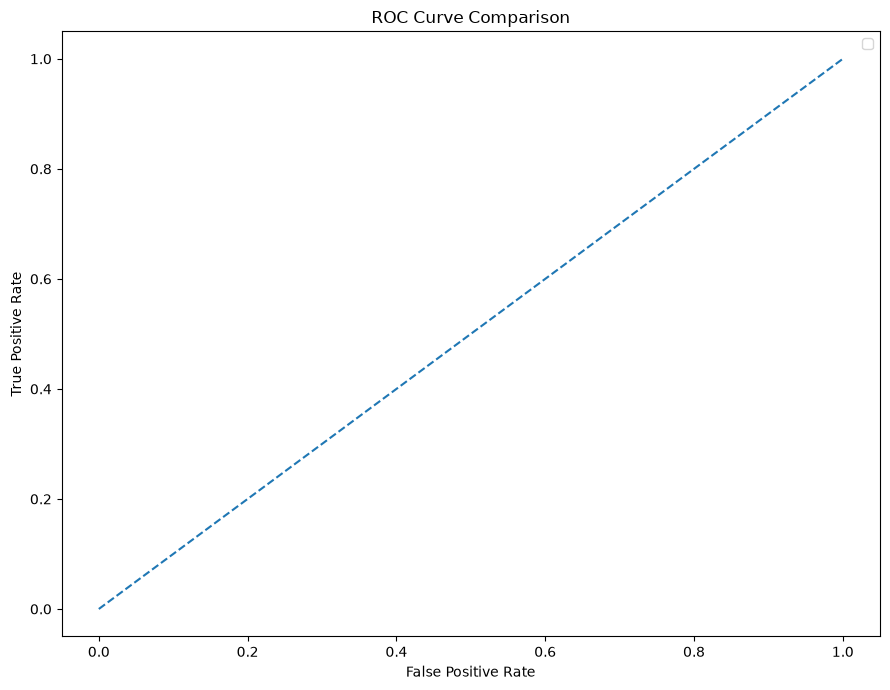

In [15]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():

    if name == "ANN":

        probability = ann_prob

    else:

        probability = model.predict_proba(
            X_test
        )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/03_roc_curves.png",
    dpi=300
)

plt.show()



NameError: name 'OUTPUT_DIR' is not defined

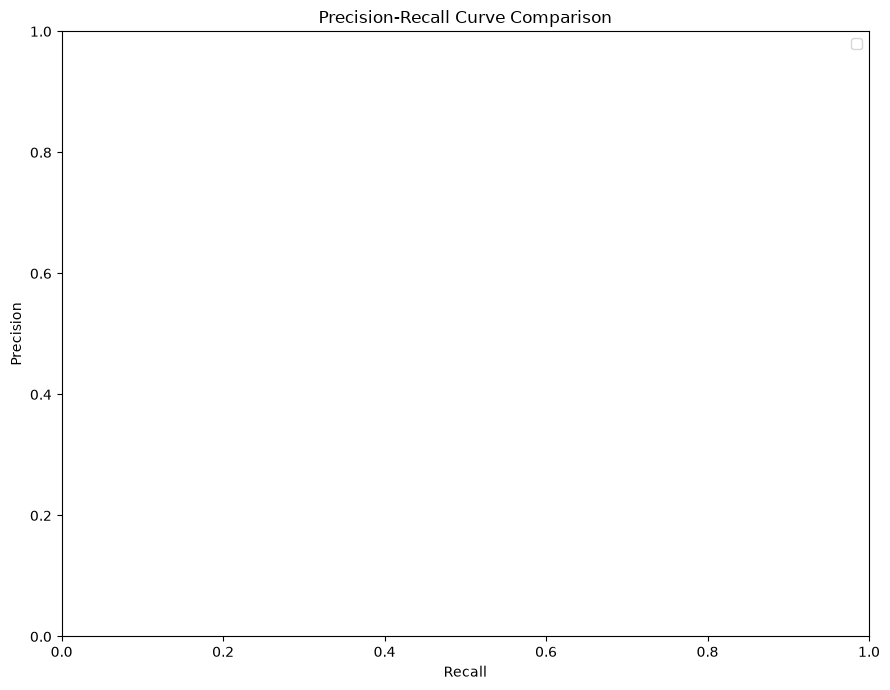

In [16]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():

    if name == "ANN":

        probability = ann_prob

    else:

        probability = model.predict_proba(
            X_test
        )[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probability
    )

    ap = average_precision_score(
        y_test,
        probability
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/04_precision_recall_curves.png",
    dpi=300
)

plt.show()


In [17]:
print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE - XGBOOST")
print("=" * 70)

xgb_model = trained_models["XGBoost"]

perm = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance_Mean":
        perm.importances_mean,

    "Importance_SD":
        perm.importances_std

}).sort_values(
    "Importance_Mean",
    ascending=False
)

print(
    importance_df.head(15)
)

importance_df.to_csv(
    f"{OUTPUT_DIR}/permutation_importance.csv",
    index=False
)


plt.figure(figsize=(9, 6))

top = importance_df.head(10)

sns.barplot(
    data=top,
    x="Importance_Mean",
    y="Feature"
)

plt.title(
    "XGBoost Permutation Feature Importance"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/05_feature_importance.png",
    dpi=300
)

plt.show()


PERMUTATION IMPORTANCE - XGBOOST


KeyError: 'XGBoost'

In [18]:
print("\n" + "=" * 70)
print("SHAP ANALYSIS")
print("=" * 70)

try:

    # Transform test data
    X_test_transformed = (
        xgb_model.named_steps[
            "preprocessor"
        ].transform(X_test)
    )

    if hasattr(
        X_test_transformed,
        "toarray"
    ):
        X_test_transformed = (
            X_test_transformed.toarray()
        )

    feature_names = (
        xgb_model.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )

    xgb_estimator = (
        xgb_model.named_steps[
            "model"
        ]
    )

    explainer = shap.TreeExplainer(
        xgb_estimator
    )

    shap_values = explainer(
        X_test_transformed
    )

    plt.figure()

    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=feature_names,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/06_xgboost_shap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

except Exception as e:

    print(
        "SHAP analysis could not be completed:",
        e
    )


SHAP ANALYSIS
SHAP analysis could not be completed: name 'xgb_model' is not defined


In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ANN Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/07_ann_loss.png",
    dpi=300
)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Training AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")

plt.title(
    "ANN Training and Validation AUC"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/08_ann_auc.png",
    dpi=300
)

plt.show()


NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

In [20]:
print("\n" + "=" * 70)
print("SAVING MODELS")
print("=" * 70)

for name, model in trained_models.items():

    if name == "ANN":

        model.save(
            f"{OUTPUT_DIR}/ANN_model.keras"
        )

    else:

        safe_name = (
            name.lower()
            .replace(" ", "_")
        )

        joblib.dump(
            model,
            f"{OUTPUT_DIR}/{safe_name}.joblib"
        )


SAVING MODELS


In [21]:
summary = {

    "Rows": len(df),

    "Columns": len(df.columns),

    "Target": TARGET,

    "Class_0":
        int((df[TARGET] == 0).sum()),

    "Class_1":
        int((df[TARGET] == 1).sum()),

    "Duplicates":
        int(df.duplicated().sum()),

    "Missing_Cells":
        int(df.isnull().sum().sum()),

    "Random_State":
        RANDOM_STATE
}

pd.DataFrame(
    [summary]
).to_csv(
    f"{OUTPUT_DIR}/dataset_summary.csv",
    index=False
)

NameError: name 'df' is not defined

In [22]:
print("\n" + "=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)

print(
    f"\nAll results saved in: {OUTPUT_DIR}/"
)

print("\nFinal comparison:")

print(
    results_df[
        display_columns
    ].round(4).to_string(index=False)
)

print("\nResearch pipeline completed successfully.")


PIPELINE COMPLETE


NameError: name 'OUTPUT_DIR' is not defined